In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_json("../data/raw_logs.json")

cols = [
    "event_hash",
    "@timestamp",
    "client_ip",
    "region_name",
    "service_id",
    "llm_provider",
    "llm_model_id",
    "llm_prompt",
    "llm_total_tokens",
    "llm_cost_usd",
    "llm_response_time_ms",
    "http_status_code",
    #"anomaly_score",
    #"label", 
    "headers_content_type", 
    "llm_prompt_category",
    "llm_status"
]

df = df[cols]

df.head()

,event_hash,@timestamp,client_ip,region_name,service_id,llm_provider,llm_model_id,llm_prompt,llm_total_tokens,llm_cost_usd,llm_response_time_ms,http_status_code,headers_content_type,llm_prompt_category,llm_status
0,0b3c3c216da58689db193ba9d6ffd1dcaa7aa46fc11a89...,2026-04-18T23:30:00.000Z,144.138.68.192,Ireland | Dublin,api-gateway,,,,,,,429,application/xml,,
1,f1ea5b3a60fad000173953593b2053cc403d1958c416a0...,2026-04-18T23:30:00.000Z,71.63.58.36,USA | Iowa (2),data-pipeline,,,,,,,200,multipart/form-data,,
2,030209a26e89baa8d0111bcfb6c4c8083edf4c807cc3f1...,2026-04-18T23:30:01.000Z,43.68.136.224,"USA | Colorado Springs, CO (2)",analytics-engine,,,,,,,200,application/json,,
3,f2fae67c4eb94e11a9a94e22e1931f291106d18c1dbd9b...,2026-04-18T23:30:02.000Z,,Mexico | Queretaro,,Anthropic,claude-3-sonnet,Evaluate the retrieval quality of the RAG pipe...,2220,0.00666,1445.1,,application/json,LLM Operations,success
4,cbb959dbea10cbc92ebe2b53d1eee24b640a46b043162d...,2026-04-18T23:30:02.000Z,130.156.51.40,Switzerland | Zürich,analytics-engine,,,,,,,200,multipart/form-data,,


### Preprocesamiento

In [3]:
df["@timestamp"] = pd.to_datetime(df["@timestamp"], errors="coerce")

In [4]:
num_cols = [
    "llm_total_tokens",
    "llm_cost_usd",
    "llm_response_time_ms",
    "http_status_code"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [5]:
# reemplaza strings vacíos o con espacios por NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

### Feature engineering

In [6]:
# filtrar solo requests LLM válidos
df_llm = df[
    df["llm_total_tokens"].notna() &
    df["llm_total_tokens"] > 0 &
    df["llm_prompt"].notna()
].copy()

In [7]:
# longitud del prompt
df_llm["prompt_length"] = df_llm["llm_prompt"].str.len()

# evitar divisiones inválidas
df_llm["prompt_length"] = df_llm["prompt_length"].replace(0, np.nan)

# features
df_llm["token_density"] = df_llm["llm_total_tokens"] / df_llm["prompt_length"]
df_llm["latency_per_token"] = df_llm["llm_response_time_ms"] / df_llm["llm_total_tokens"]
df_llm["cost_intensity"] = df_llm["llm_cost_usd"] / df_llm["llm_total_tokens"]

In [8]:
df_llm.head()

,event_hash,@timestamp,client_ip,region_name,service_id,llm_provider,llm_model_id,llm_prompt,llm_total_tokens,llm_cost_usd,llm_response_time_ms,http_status_code,headers_content_type,llm_prompt_category,llm_status,prompt_length,token_density,latency_per_token,cost_intensity
3,f2fae67c4eb94e11a9a94e22e1931f291106d18c1dbd9b...,2026-04-18 23:30:02+00:00,NaN,Mexico | Queretaro,NaN,Anthropic,claude-3-sonnet,Evaluate the retrieval quality of the RAG pipe...,2220.0,0.006660,1445.10,NaN,application/json,LLM Operations,success,110,20.181818,0.650946,3.000000e-06
7,aaba76d4f906f37514c163addc6914d8f577510570becb...,2026-04-18 23:30:04+00:00,NaN,Thailand | Bangkok,NaN,Mistral,mistral-small-4,Draft OKRs for the sap-s4hana-sales team in Th...,1338.0,0.000401,4264.29,NaN,multipart/form-data,Productivity,success,116,11.534483,3.187063,2.997010e-07
8,1d7f34f65994010ef98ea47a8e1f4b8a3fe6962280cb32...,2026-04-18 23:30:04+00:00,NaN,France | Paris,NaN,Google,gemini-2.0-flash,Create a meeting agenda for a 30-minute review...,1520.0,0.000608,13914.68,NaN,application/xml,Productivity,success,97,15.670103,9.154395,4.000000e-07
9,8f1785ee30b9079a385fbcba5eae4a718d9def11bd9f82...,2026-04-18 23:30:05+00:00,NaN,"USA | Elk Grove Village, IL",NaN,Google,gemini-3.1-pro,Analyse warehouse utilisation rates for sap-ar...,2290.0,0.018320,3451.40,NaN,application/json,Supply Chain,success,115,19.913043,1.507162,8.000000e-06
11,76625d4b1c3d8aefeb4f833fd7c3613943314f4f409d09...,2026-04-18 23:30:08+00:00,NaN,Germany | South,NaN,Google,gemini-2.0-flash,Forecast cash flow for sap-s4hana-sales over t...,2354.0,0.000942,9024.87,NaN,multipart/form-data,Finance,success,105,22.419048,3.833845,4.001699e-07


In [9]:
# % de valores nulos
pct_null = df_llm.isna().mean() * 100
pct_null

event_hash                0.0
@timestamp                0.0
client_ip               100.0
region_name               0.0
service_id              100.0
llm_provider              0.0
llm_model_id              0.0
llm_prompt                0.0
llm_total_tokens          0.0
llm_cost_usd              0.0
llm_response_time_ms      0.0
http_status_code        100.0
headers_content_type      0.0
llm_prompt_category       0.0
llm_status                0.0
prompt_length             0.0
token_density             0.0
latency_per_token         0.0
cost_intensity            0.0
dtype: float64

In [10]:
df_llm = df_llm.dropna(axis=1)

In [11]:
df_llm.head()

,event_hash,@timestamp,region_name,llm_provider,llm_model_id,llm_prompt,llm_total_tokens,llm_cost_usd,llm_response_time_ms,headers_content_type,llm_prompt_category,llm_status,prompt_length,token_density,latency_per_token,cost_intensity
3,f2fae67c4eb94e11a9a94e22e1931f291106d18c1dbd9b...,2026-04-18 23:30:02+00:00,Mexico | Queretaro,Anthropic,claude-3-sonnet,Evaluate the retrieval quality of the RAG pipe...,2220.0,0.006660,1445.10,application/json,LLM Operations,success,110,20.181818,0.650946,3.000000e-06
7,aaba76d4f906f37514c163addc6914d8f577510570becb...,2026-04-18 23:30:04+00:00,Thailand | Bangkok,Mistral,mistral-small-4,Draft OKRs for the sap-s4hana-sales team in Th...,1338.0,0.000401,4264.29,multipart/form-data,Productivity,success,116,11.534483,3.187063,2.997010e-07
8,1d7f34f65994010ef98ea47a8e1f4b8a3fe6962280cb32...,2026-04-18 23:30:04+00:00,France | Paris,Google,gemini-2.0-flash,Create a meeting agenda for a 30-minute review...,1520.0,0.000608,13914.68,application/xml,Productivity,success,97,15.670103,9.154395,4.000000e-07
9,8f1785ee30b9079a385fbcba5eae4a718d9def11bd9f82...,2026-04-18 23:30:05+00:00,"USA | Elk Grove Village, IL",Google,gemini-3.1-pro,Analyse warehouse utilisation rates for sap-ar...,2290.0,0.018320,3451.40,application/json,Supply Chain,success,115,19.913043,1.507162,8.000000e-06
11,76625d4b1c3d8aefeb4f833fd7c3613943314f4f409d09...,2026-04-18 23:30:08+00:00,Germany | South,Google,gemini-2.0-flash,Forecast cash flow for sap-s4hana-sales over t...,2354.0,0.000942,9024.87,multipart/form-data,Finance,success,105,22.419048,3.833845,4.001699e-07


## EDA

In [12]:
import pandas as pd

# columnas categóricas
cat_cols = [
    "region_name",
    "llm_provider",
    "llm_model_id",
    "headers_content_type",
    "llm_prompt_category",
    "llm_status"
]

# numérica
num_cols = ["prompt_length"]

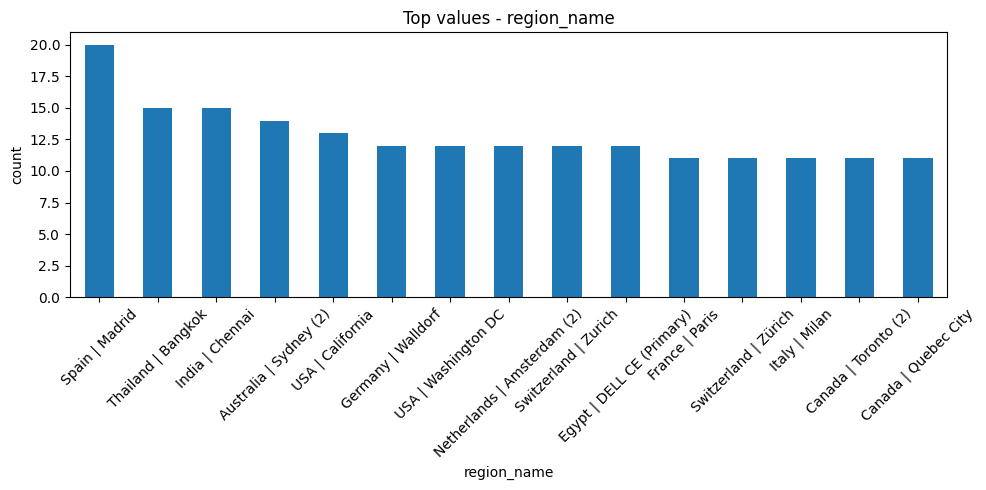

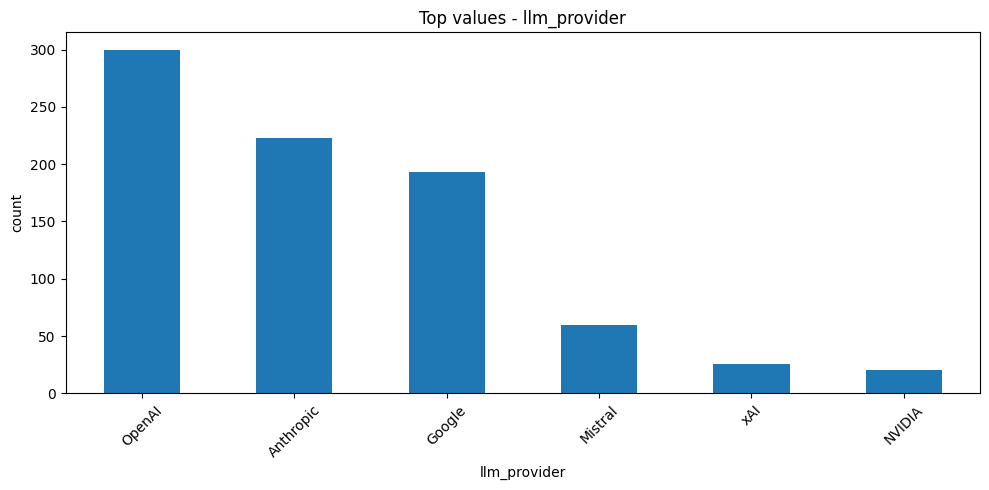

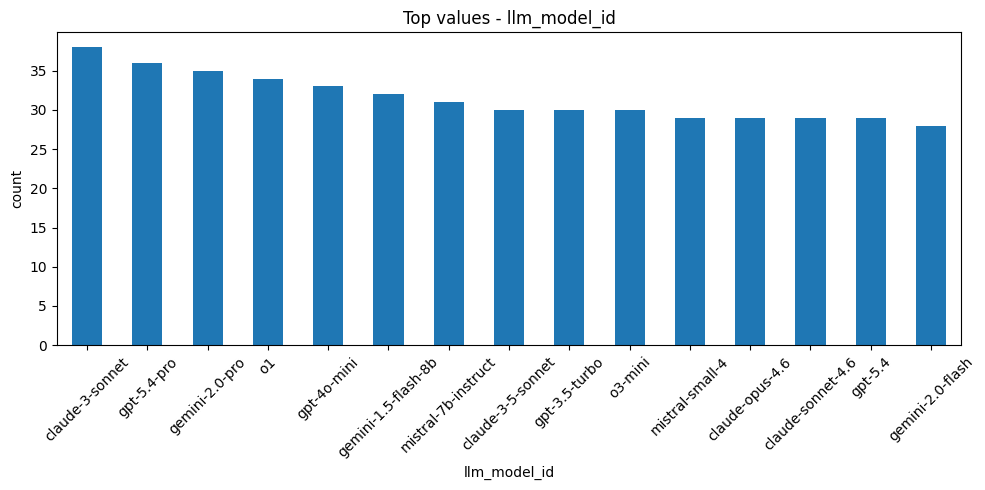

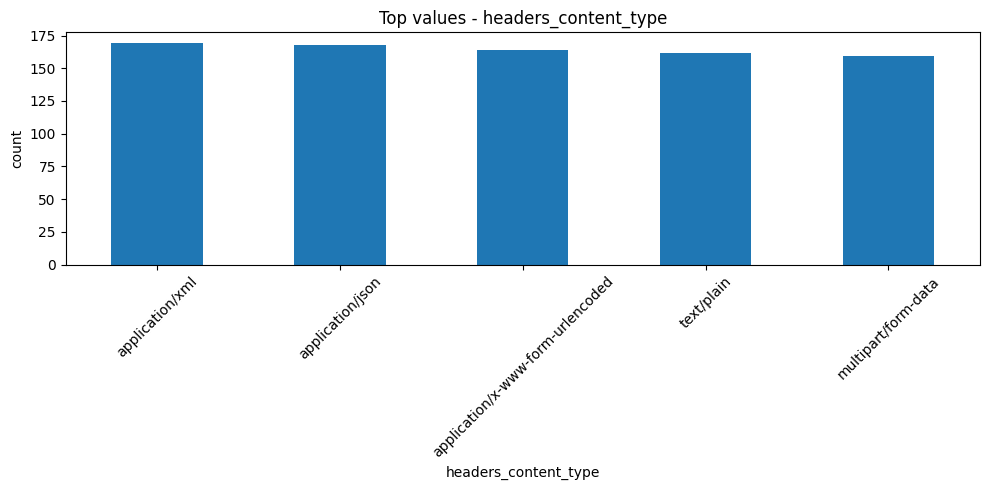

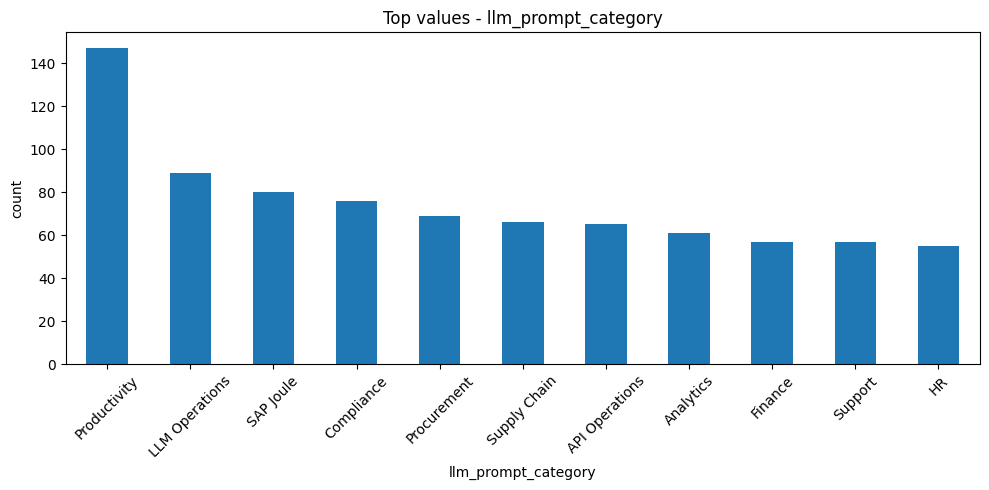

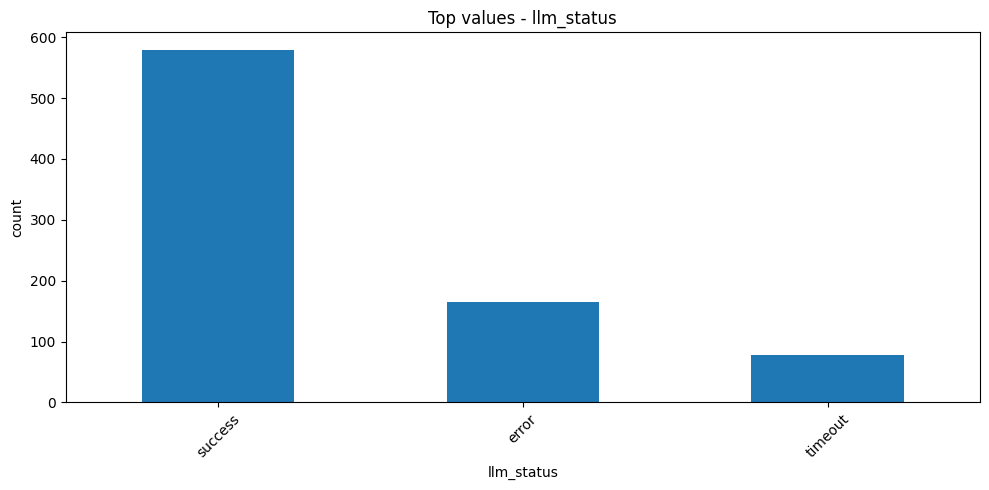

In [13]:
for col in cat_cols:
    plt.figure(figsize=(10,5))
    
    df_llm[col].value_counts().head(15).plot(kind="bar")
    
    plt.title(f"Top values - {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

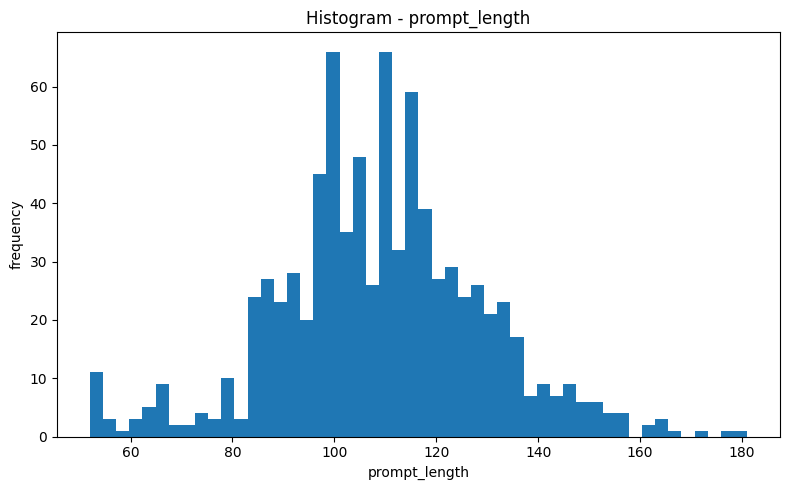

In [14]:
for col in num_cols:
    plt.figure(figsize=(8,5))
    
    df_llm[col].dropna().plot(kind="hist", bins=50)
    
    plt.title(f"Histogram - {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    
    plt.tight_layout()
    plt.show()

In [15]:
df_llm[df_llm['llm_status'] == "error"]

,event_hash,@timestamp,region_name,llm_provider,llm_model_id,llm_prompt,llm_total_tokens,llm_cost_usd,llm_response_time_ms,headers_content_type,llm_prompt_category,llm_status,prompt_length,token_density,latency_per_token,cost_intensity
27,10ede41c4f4c5c61d7b4be56a08087e873565b8fe76d17...,2026-04-18 23:30:15+00:00,Switzerland | Zürich,Anthropic,claude-sonnet-4.6,Assess the impact of the supply chain disrupti...,544.0,0.002176,211.81,multipart/form-data,Supply Chain,error,115,4.730435,0.389357,4.000000e-06
49,2dbba2ce0c252c36d28f535ab516cc9a79eea83c0cd363...,2026-04-18 23:30:28+00:00,Brazil | São Paulo,Anthropic,claude-opus-4.6,Generate a response quality report for the sap...,1698.0,0.030564,608.43,multipart/form-data,LLM Operations,error,144,11.791667,0.358322,1.800000e-05
61,b01fe763ca75ddf3072f685c20b89066f7315abaaab175...,2026-04-18 23:30:33+00:00,Canada | Toronto,OpenAI,gpt-5.4-pro,Perform a root cause analysis for the recurrin...,2202.0,0.088080,1572.66,multipart/form-data,Support,error,116,18.982759,0.714196,4.000000e-05
93,043d444d2d8f3b91c07cc70e763ec03e33e503fe0bda35...,2026-04-18 23:30:45+00:00,China | Shanghai,OpenAI,o1,I was working on sap-data-sphere and got inter...,1446.0,0.021690,200.13,multipart/form-data,Productivity,error,107,13.514019,0.138402,1.500000e-05
97,6779f0b7c71da9a6b625cf5cec45e769c4464278149890...,2026-04-18 23:30:47+00:00,Germany | Walldorf,OpenAI,gpt-4o,Generate a succession planning summary for key...,1981.0,0.009905,1083.11,text/plain,HR,error,135,14.674074,0.546749,5.000000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3861,c16fd8bb55f5e4288d965400eb8076ed3db53e5ed36097...,2026-04-18 23:59:37+00:00,Germany | St. Leon Rot,OpenAI,gpt-5.4,Summarise the top three risks for the sap-anal...,284.0,0.005680,1094.95,application/xml,Productivity,error,116,2.448276,3.855458,2.000000e-05
3868,3e4ca7199bc3e4640b9369fa9dc362c743d706168d8344...,2026-04-18 23:59:40+00:00,"USA | Moncks Corner, SC",Anthropic,claude-3-5-haiku,Review the observability setup for sap-success...,2253.0,0.001802,1872.86,application/x-www-form-urlencoded,API Operations,error,130,17.330769,0.831274,7.998225e-07
3901,1c6144d7a2f0892a3e8e4ea15ee3aa9e8446eb2efe4f94...,2026-04-18 23:59:54+00:00,India | Chennai,OpenAI,gpt-5.4-pro,Perform due diligence on vendor NexaGroup befo...,1816.0,0.072640,424.10,application/xml,Compliance,error,152,11.947368,0.233535,4.000000e-05
3903,0e33bc658cd885a841f03fb0a16202bf6ba0b1ec95c78e...,2026-04-18 23:59:56+00:00,Spain | Madrid,OpenAI,o1,Draft a contract renewal recommendation for ve...,2266.0,0.033990,1630.61,text/plain,Procurement,error,83,27.301205,0.719598,1.500000e-05


**Variable Binaria**

In [16]:
df_llm["is_error"] = df_llm["llm_status"].str.contains("error", case=False, na=False)

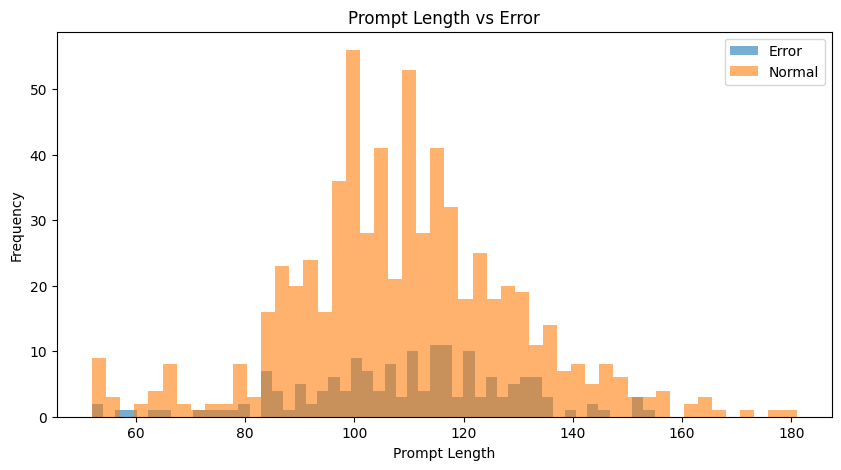

In [17]:
plt.figure(figsize=(10,5))

plt.hist(df_llm[df_llm["is_error"]]["prompt_length"], bins=50, alpha=0.6, label="Error")
plt.hist(df_llm[~df_llm["is_error"]]["prompt_length"], bins=50, alpha=0.6, label="Normal")

plt.xlabel("Prompt Length")
plt.ylabel("Frequency")
plt.title("Prompt Length vs Error")
plt.legend()

plt.show()

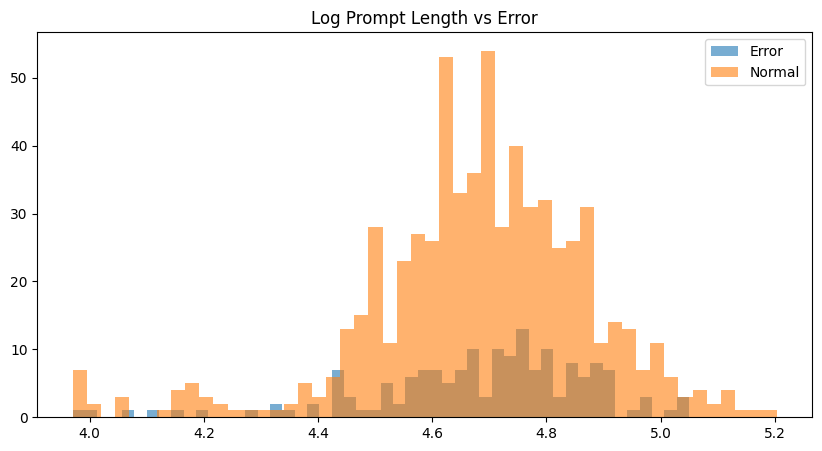

In [18]:
plt.figure(figsize=(10,5))

plt.hist(np.log1p(df_llm[df_llm["is_error"]]["prompt_length"]), bins=50, alpha=0.6, label="Error")
plt.hist(np.log1p(df_llm[~df_llm["is_error"]]["prompt_length"]), bins=50, alpha=0.6, label="Normal")

plt.title("Log Prompt Length vs Error")
plt.legend()

plt.show()

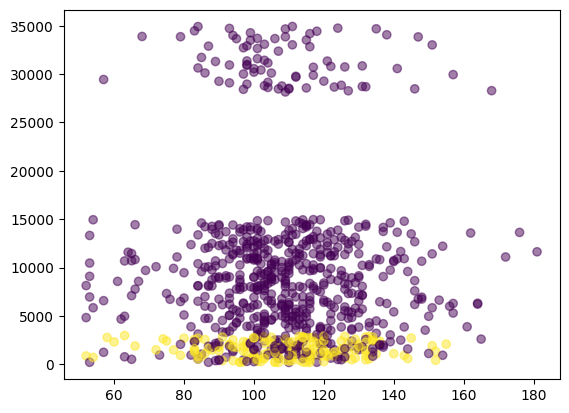

In [19]:
plt.scatter(
    df_llm["prompt_length"],
    df_llm["llm_response_time_ms"],
    c=df_llm["is_error"].astype(int),
    alpha=0.5
)

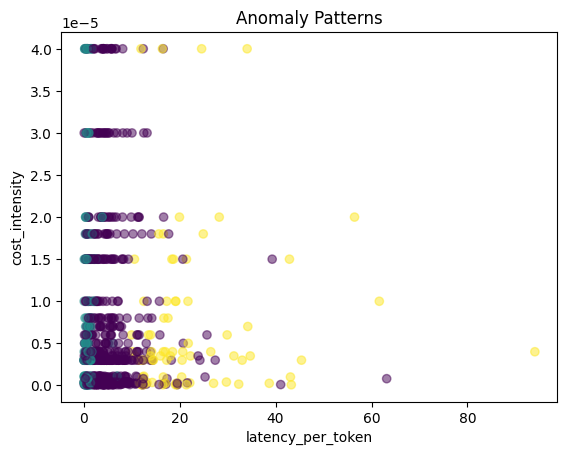

In [20]:
plt.scatter(
    df_llm["latency_per_token"],
    df_llm["cost_intensity"],
    c=df_llm["llm_status"].map({"success":0, "error":1, "timeout":2}),
    alpha=0.5
)

plt.xlabel("latency_per_token")
plt.ylabel("cost_intensity")
plt.title("Anomaly Patterns")
plt.show()

In [21]:
def plot_error_rate(df, col, top_n=15):
    # calcular tasa de error por categoría
    temp = df.groupby(col)["is_error"].mean().sort_values(ascending=False).head(top_n)
    
    plt.figure(figsize=(10,5))
    temp.plot(kind="bar")
    
    plt.title(f"Error Rate by {col}")
    plt.ylabel("Error Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

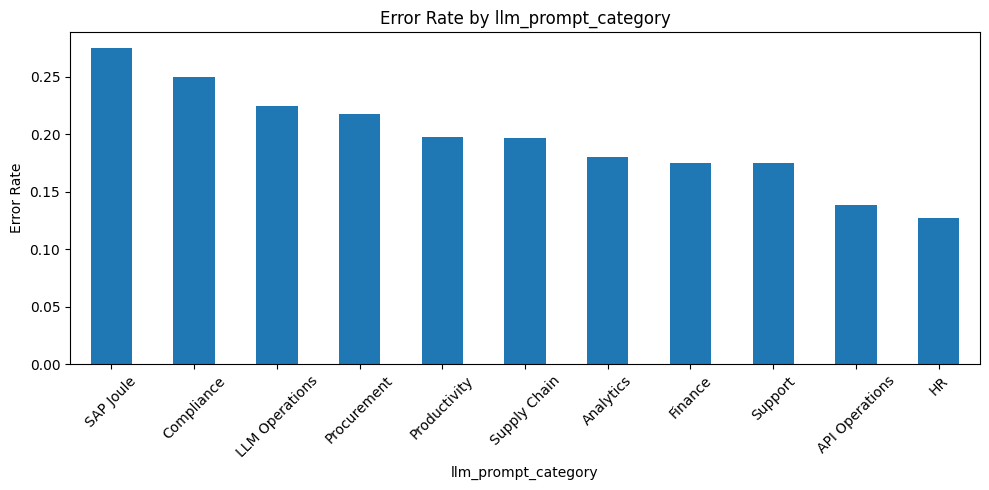

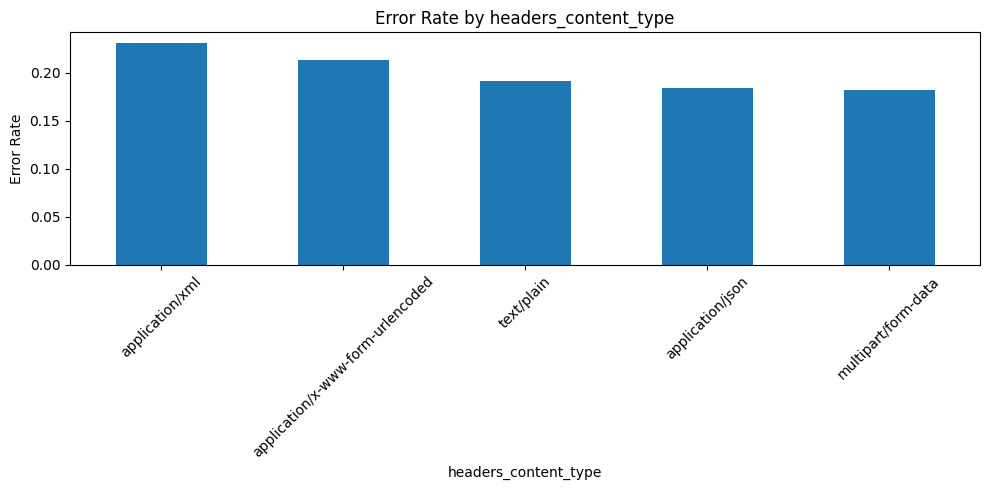

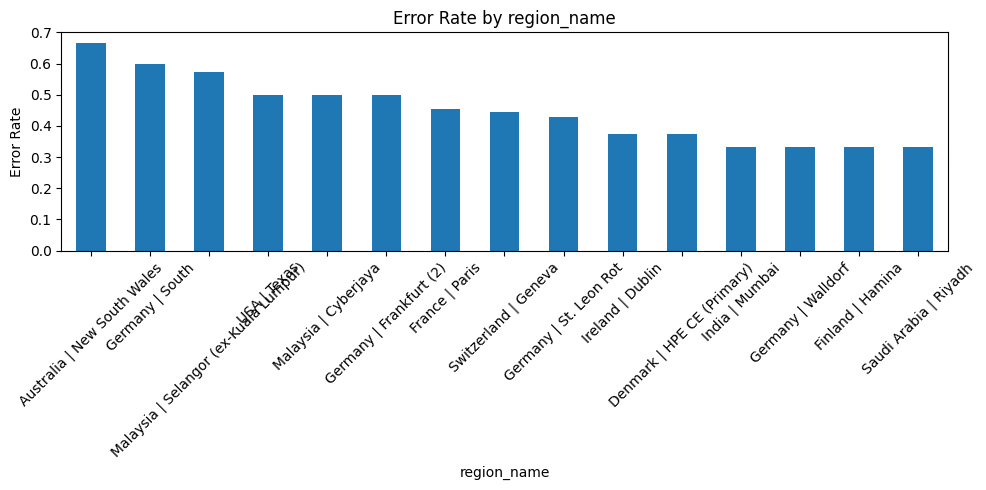

In [22]:
plot_error_rate(df_llm, "llm_prompt_category")
plot_error_rate(df_llm, "headers_content_type")
plot_error_rate(df_llm, "region_name")

In [23]:
pd.set_option('display.max_colwidth', None)

In [24]:
df_llm.shape

(822, 17)

In [25]:
for cat in df_llm["llm_status"].unique():
    if cat != "success": 
        print(f"\n=== {cat} ===")
        print(df_llm[df_llm["llm_status"] == cat]["llm_prompt"].head(20))
    else: 
        pass



=== error ===
27                                          Assess the impact of the supply chain disruption in Switzerland | Zürich on sap-analytics-cloud fulfilment targets.
49             Generate a response quality report for the sap-successfactors LLM pipeline in Brazil | São Paulo covering accuracy, relevance, and tone metrics.
61                                         Perform a root cause analysis for the recurring error BDOC_TRANSFER_ERROR in sap-concur and propose a permanent fix.
93                                                  I was working on sap-data-sphere and got interrupted. Summarise where I left off and suggest the next step.
97                      Generate a succession planning summary for key roles in sap-analytics-cloud within Germany | Walldorf and identify internal candidates.
107                                                                                  Summarise the audit findings for sap-btp-cf and propose remediation steps.
114                      

In [26]:
df_llm["llm_prompt"].value_counts()

llm_prompt
Compare the two proposed approaches for sap-concur and recommend the better option with reasoning.                                                          3
Review SOX controls for sap-analytics-cloud financial reporting processes and identify deficiencies.                                                        3
Summarize open support tickets related to sap-ariba.                                                                                                        3
Summarise LLM API token consumption for sap-btp-cf over the past 30 days and highlight cost drivers.                                                        3
What KPIs are underperforming in sap-s4hana-finance this quarter?                                                                                           2
                                                                                                                                                           ..
Draft a professional reply to the email t

In [27]:
df_llm[df_llm["is_error"]]["llm_prompt"].value_counts().head(10)

llm_prompt
Audit the sap-intelligent-rpa prompt templates for potential injection vulnerabilities and recommend sanitisation measures.                         2
Assess the impact of the supply chain disruption in Switzerland | Zürich on sap-analytics-cloud fulfilment targets.                                 1
Generate a response quality report for the sap-successfactors LLM pipeline in Brazil | São Paulo covering accuracy, relevance, and tone metrics.    1
Perform a root cause analysis for the recurring error BDOC_TRANSFER_ERROR in sap-concur and propose a permanent fix.                                1
I was working on sap-data-sphere and got interrupted. Summarise where I left off and suggest the next step.                                         1
Generate a succession planning summary for key roles in sap-analytics-cloud within Germany | Walldorf and identify internal candidates.             1
Summarise the audit findings for sap-btp-cf and propose remediation steps.               

In [28]:
df_llm.groupby("llm_prompt_category")["prompt_length"].mean().sort_values(ascending=False)

llm_prompt_category
API Operations    117.153846
LLM Operations    115.157303
Compliance        114.368421
Supply Chain      113.757576
HR                109.327273
SAP Joule         109.025000
Productivity      108.374150
Support           108.035088
Finance           103.140351
Procurement       102.623188
Analytics          95.557377
Name: prompt_length, dtype: float64

In [29]:
def classify_prompt(prompt):
    if pd.isna(prompt):
        return "unknown"
    
    prompt = prompt.lower()
    
    if any(x in prompt for x in ["summarise", "summarize"]):
        return "summarization"
    if any(x in prompt for x in ["generate", "draft", "write"]):
        return "generation"
    if any(x in prompt for x in ["forecast", "predict", "benchmark"]):
        return "analysis"
    if any(x in prompt for x in ["error", "failure"]):
        return "system_task"
    
    return "other"

df_llm["task_type"] = df_llm["llm_prompt"].apply(classify_prompt)

In [30]:
df_llm.groupby("task_type")["is_error"].mean().sort_values(ascending=False) * 100

task_type
generation       22.707424
other            20.506912
summarization    18.181818
analysis         13.333333
system_task       7.692308
Name: is_error, dtype: float64

## Modelo

In [31]:
df_normal = df_llm[df_llm["llm_status"] == "success"]

In [32]:
from sklearn.ensemble import IsolationForest

X = df_normal[[
    "llm_total_tokens",
    "llm_response_time_ms",
    "latency_per_token",
    "cost_intensity",
    "token_density"
]].dropna()

model = IsolationForest(contamination=0.02)
model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [33]:
df_llm["anomaly_isof"] = model.predict(
    df_llm[X.columns].fillna(0)
)

In [34]:
pd.crosstab(df_llm["anomaly_isof"], df_llm["llm_status"])

llm_status,error,success,timeout
anomaly_isof,,,
-1,4,12,24
1,161,567,54


De las 34 instancias marcadas como anómalas, la mayoría corresponden a fallas reales (timeouts y algunos errores), lo cual es positivo, pero al mismo tiempo está ignorando la gran mayoría de errores totales (solo detecta ~2% de errores y ~24% de timeouts), lo que indica que muchos fallos ocurren dentro de patrones “normales” aprendidos por el modelo; en otras palabras, no todo error es una anomalía y tu modelo está aprendiendo eso correctamente. 


In [35]:
num_features = [
    "llm_total_tokens",
    "llm_response_time_ms",
    "latency_per_token",
    "cost_intensity",
    "token_density",
    "prompt_length"
]

In [36]:
cat_features = [
    "llm_provider",
    "llm_model_id",
    "headers_content_type",
    "llm_prompt_category",
    "task_type"
]

In [37]:
df_llm["headers_content_type"] = df_llm["headers_content_type"].str.split(";").str[0]

In [38]:
df_cat = pd.get_dummies(df_llm[cat_features], drop_first=True)

In [39]:
X = pd.concat([
    df_llm[num_features],
    df_cat
], axis=1).dropna()

In [40]:
df_normal = df_llm[df_llm["llm_status"] == "success"]

X_train = X.loc[df_normal.index]

from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.05,   # sube un poco para más sensibilidad
    n_estimators=200,
    random_state=42
)

model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [41]:
df_llm["anomaly_isof"] = model.predict(X)

In [42]:
pd.crosstab(df_llm["anomaly_isof"], df_llm["llm_status"])

llm_status,error,success,timeout
anomaly_isof,,,
-1,7,29,7
1,158,550,71


In [45]:
df_llm.loc[df_llm['anomaly_isof'] == -1,
           ["llm_prompt", "anomaly_isof"]]

,llm_prompt,anomaly_isof
28,Generate a trend report for sap-s4hana-finance usage metrics in Italy | Milan over the past 6 months.,-1
38,"Summarise exit interview themes for employees who left sap-intelligent-rpa in USA | Moncks Corner, SC during Q4 and suggest retention actions.",-1
61,Perform a root cause analysis for the recurring error BDOC_TRANSFER_ERROR in sap-concur and propose a permanent fix.,-1
107,Summarise the audit findings for sap-btp-cf and propose remediation steps.,-1
167,Summarize the latest sales report for region India | Chennai.,-1
405,Generate an onboarding checklist for new employees joining sap-data-sphere in USA | California.,-1
414,"Draft a professional reply to the email thread about sap-intelligent-rpa from the USA | Ashburn, VA (2) team.",-1
435,Benchmark compensation for sap-s4hana-finance roles in Ireland | Dublin against current market data.,-1
566,"Generate a succession planning summary for key roles in sap-ariba within USA | Columbus, OH and identify internal candidates.",-1
716,Summarise the tax provision calculation for sap-s4hana-sales in India | Delhi for Q4.,-1


## SVM - One Class

In [46]:
# split: entrena solo con normales
idx_train = df_llm["llm_status"] == "success"
X_train = X.loc[idx_train]
X_test  = X  # evalúas en todo

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [48]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)  # nu≈contamination
ocsvm.fit(X_train_s)

pred_svm = ocsvm.predict(X_test_s)   # -1 anomalía, 1 normal
df_llm["anom_svm"] = pred_svm

## TDA

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# reducción (TDA mejora en menor dimensión)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [50]:
from ripser import ripser
import numpy as np

# separar grupos
idx_success = df_llm["llm_status"] == "success"
idx_fail = df_llm["llm_status"].isin(["error", "timeout"])

X_success = X_pca[idx_success]
X_fail = X_pca[idx_fail]

# calcular diagramas
dgms_success = ripser(X_success, maxdim=1)["dgms"]
dgms_fail = ripser(X_fail, maxdim=1)["dgms"]

In [51]:
def topo_features(diagrams):
    features = []
    
    for dim in diagrams:
        lifetimes = dim[:, 1] - dim[:, 0]
        lifetimes = lifetimes[np.isfinite(lifetimes)]
        
        if len(lifetimes) == 0:
            features.extend([0, 0, 0])
        else:
            features.extend([
                lifetimes.mean(),
                lifetimes.std(),
                lifetimes.max()
            ])
    
    return features

feat_success = topo_features(dgms_success)
feat_fail = topo_features(dgms_fail)

In [52]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=30).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)

topo_features_list = []

for idx in indices:
    subset = X_pca[idx]
    dgms = ripser(subset, maxdim=1)["dgms"]
    topo_features_list.append(topo_features(dgms))

import pandas as pd
df_topo = pd.DataFrame(topo_features_list, columns=[
    "h0_mean", "h0_std", "h0_max",
    "h1_mean", "h1_std", "h1_max"
])

In [53]:
X_tda = pd.concat([
    X.reset_index(drop=True),
    df_topo
], axis=1).dropna()

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
# =========================
# 1. PREPARACIÓN
# =========================

# Asegurar alineación
df = df_llm.copy()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducción dimensional (para TDA)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 2. TDA LOCAL (features topológicos)
# =========================

def topo_features(diagrams):
    features = []
    for dim in diagrams:
        lifetimes = dim[:, 1] - dim[:, 0]
        lifetimes = lifetimes[np.isfinite(lifetimes)]
        
        if len(lifetimes) == 0:
            features.extend([0, 0, 0])
        else:
            features.extend([
                lifetimes.mean(),
                lifetimes.std(),
                lifetimes.max()
            ])
    return features

# vecinos locales
nbrs = NearestNeighbors(n_neighbors=30).fit(X_pca)
_, indices = nbrs.kneighbors(X_pca)

topo_list = []

for idx in indices:
    subset = X_pca[idx]
    dgms = ripser(subset, maxdim=1)["dgms"]
    topo_list.append(topo_features(dgms))

df_topo = pd.DataFrame(topo_list, index=X.index, columns=[
    "h0_mean", "h0_std", "h0_max",
    "h1_mean", "h1_std", "h1_max"
])

# 3. COMBINAR FEATURES


X_tda = pd.concat([X, df_topo], axis=1).dropna()

# alinear df
df_aligned = df.loc[X_tda.index].copy()

# 4. TRAIN ( success)

idx_train = df_aligned["llm_status"] == "success"
X_train = X_tda.loc[idx_train]

model = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=42
)

model.fit(X_train)

# 5. PREDICCIÓN
df_llm["anomaly_tda"] = np.nan

# predicciones solo para filas válidas (X_tda)
preds = model.predict(X_tda)

# asignar respetando índice
df_llm.loc[X_tda.index, "anomaly_tda"] = preds

# (opcional) convertir a int
df_llm["anomaly_tda"] = df_llm["anomaly_tda"].astype("Int64")


In [55]:
groups = {
    "success": df_llm["llm_status"] == "success",
    "error": df_llm["llm_status"] == "error",
    "timeout": df_llm["llm_status"] == "timeout"
}

In [56]:
from ripser import ripser

diagrams_all = {}

for name, mask in groups.items():
    X_group = X_pca[mask]
    
    if len(X_group) > 500:
        X_group = X_group[:500]
    
    dgms = ripser(X_group, maxdim=1)["dgms"]
    diagrams_all[name] = dgms

In [57]:
all_h1 = np.vstack([
    dgms[1] for dgms in diagrams_all.values()
    if len(dgms[1]) > 0
])

birth_min, death_max = all_h1.min(), all_h1.max()

In [58]:
from persim import PersistenceImager

pimgr = PersistenceImager(
    pixel_size=0.1,
    birth_range=(birth_min, death_max),
    pers_range=(0, death_max - birth_min)
)

In [59]:
images = {}

for name, dgms in diagrams_all.items():
    img = pimgr.transform(dgms[1])
    images[name] = img

In [60]:
diff_error = images["error"] - images["success"]
diff_timeout = images["timeout"] - images["success"]

In [61]:
# revisa cuántos puntos hay en cada dimensión
for name, dgms in diagrams_all.items():
    print(name, "H0:", len(dgms[0]), "H1:", len(dgms[1]))

success H0: 500 H1: 331
error H0: 165 H1: 84
timeout H0: 78 H1: 38


In [62]:
dim_to_use = 1 if all(len(dgms[1]) > 0 for dgms in diagrams_all.values()) else 0
print("Usando dimensión:", dim_to_use)

Usando dimensión: 1


In [63]:
import numpy as np
from persim import PersistenceImager

all_pts = np.vstack([
    dgms[dim_to_use] for dgms in diagrams_all.values()
    if len(dgms[dim_to_use]) > 0
])

birth_min, death_max = all_pts.min(), all_pts.max()

pimgr = PersistenceImager(
    pixel_size=0.1,
    birth_range=(birth_min, death_max),
    pers_range=(0, death_max - birth_min)
)

In [64]:
images = {}

for name, dgms in diagrams_all.items():
    if len(dgms[dim_to_use]) == 0:
        print(f"{name} vacío, saltando")
        continue
    
    img = pimgr.transform(dgms[dim_to_use])
    images[name] = img
    print(name, img.shape, "min/max:", img.min(), img.max())

success (80, 80) min/max: 6.838514874829428e-17 0.08219292140609767
error (80, 80) min/max: -7.760449688294895e-17 0.025875702461153897
timeout (80, 80) min/max: -6.947239825415643e-17 0.017258381017938695


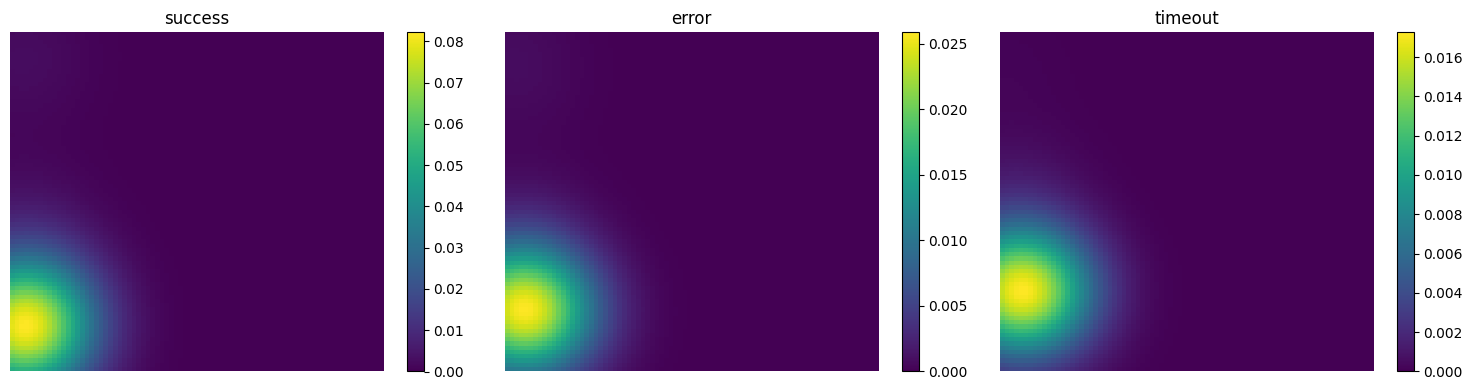

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 4))

if len(images) == 1:
    axes = [axes]

for ax, (name, img) in zip(axes, images.items()):
    im = ax.imshow(img, origin="lower", aspect="auto")
    ax.set_title(name)
    ax.axis("off")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Autoencoder

In [66]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# arquitectura del Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Instanciar modelo
input_dim = X_train_s.shape[1]
model = Autoencoder(input_dim)

#Convertir arrays de Numpy a Tensores de PyTorch
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)

# Crear DataLoader para manejar los batches
dataset = TensorDataset(X_train_tensor, X_train_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

# 3. Configurar optimizador y función de pérdida
optimizer = optim.Adam(model.parameters())
criterion = nn.MSELoss()

# 4. Bucle de entrenamiento (Equivalente a autoencoder.fit)
epochs = 20
model.train() # 

for epoch in range(epochs):
    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()         # Limpiar gradientes
        outputs = model(batch_x)      # Forward pass (predicción)
        loss = criterion(outputs, batch_y) # Calcular pérdida
        loss.backward()               # Backward pass (cálculo de gradientes)
        optimizer.step()              # Actualizar pesos

# 5. Evaluación y cálculo de reconstrucción
model.eval()
with torch.no_grad():
    
    recon_test = model(X_test_tensor)
    mse = ((X_test_tensor - recon_test) ** 2).mean(dim=1).numpy()
    
    recon_train = model(X_train_tensor)
    train_mse = ((X_train_tensor - recon_train) ** 2).mean(dim=1).numpy()
    thr = np.percentile(train_mse, 95)

# 6. Asignar anomalías
df_llm["anom_ae"] = np.where(mse > thr, -1, 1) # -1 = anomalía

In [67]:
from ripser import ripser
from sklearn.decomposition import PCA

# reduce dimensionalidad para TDA
X_tda = PCA(n_components=10).fit_transform(X_test_s)

diagrams = ripser(X_tda, maxdim=1)["dgms"]
# inspecciona diagramas de persistencia (H0, H1)

In [68]:
columnas_preds = ['anomaly_isof', 'anom_svm', 'anom_ae', 'anomaly_tda']

In [69]:
print(df_llm[columnas_preds].corr())

              anomaly_isof  anom_svm   anom_ae  anomaly_tda
anomaly_isof      1.000000  0.221378  0.356680     0.521971
anom_svm          0.221378  1.000000  0.603946     0.291573
anom_ae           0.356680  0.603946  1.000000     0.539364
anomaly_tda       0.521971  0.291573  0.539364     1.000000


Se destaca una correlación máxima de 0.60 entre el Autoencoder y el SVM que sugiere cierta redundancia en la captura de anomalías por distancia espacial. 
Por otro lado, las bajas correlaciones del Isolation Forest y TDA confirman que estos capturan dimensiones ortogonales de aislamiento y estructura topológica, respectivamente. 

In [70]:
df_llm['votos_anomalia'] = (df_llm[columnas_preds] == -1).sum(axis=1)

In [71]:
pd.set_option('display.max_colwidth', None)

# Filtrar casos donde hay conflicto (ej. exactamente 2 modelos lo marcan como anomalía)
casos_en_conflicto = df_llm[df_llm['votos_anomalia'] == 2]
casos_en_conflicto[['llm_prompt'] + columnas_preds].head(10)

,llm_prompt,anomaly_isof,anom_svm,anom_ae,anomaly_tda
38,"Summarise exit interview themes for employees who left sap-intelligent-rpa in USA | Moncks Corner, SC during Q4 and suggest retention actions.",-1,-1,1,1
107,Summarise the audit findings for sap-btp-cf and propose remediation steps.,-1,-1,1,1
113,Summarise the audit findings for sap-successfactors and propose remediation steps.,1,-1,-1,1
119,Write a knowledge-base article explaining how to resolve error BDOC_TRANSFER_ERROR in sap-btp-cf.,1,-1,-1,1
242,Have SAP Joule draft an approval request for the budget exception in sap-analytics-cloud.,1,-1,-1,1
275,Create a stakeholder map for the sap-concur rollout in USA | HPE CE and classify each stakeholder by influence and interest.,1,-1,-1,1
282,Suggest prompt optimisations to reduce token usage for the sap-analytics-cloud inference pipeline.,1,-1,-1,1
435,Benchmark compensation for sap-s4hana-finance roles in Ireland | Dublin against current market data.,-1,1,1,-1
475,Summarise feature adoption rates for sap-analytics-cloud in UAE | Abu Dhabi over the past quarter.,1,-1,-1,1
603,Create a stakeholder map for the sap-successfactors rollout in Malaysia | Selangor (ex-Kuala Lumpur) and classify each stakeholder by influence and interest.,1,-1,-1,1
